In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("Libraries loaded ✅")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✅


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14676\2886743398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])


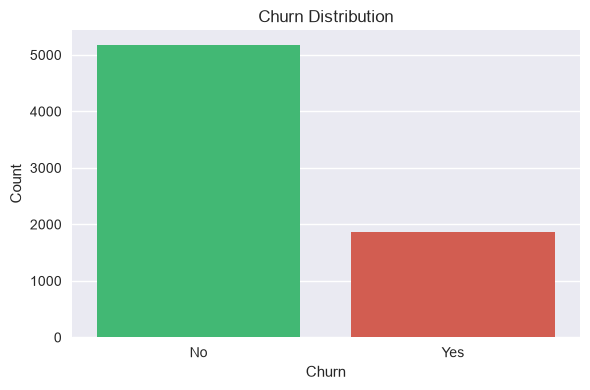

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(f"\nChurn rate: {churn_pct['Yes']:.1f}%")

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

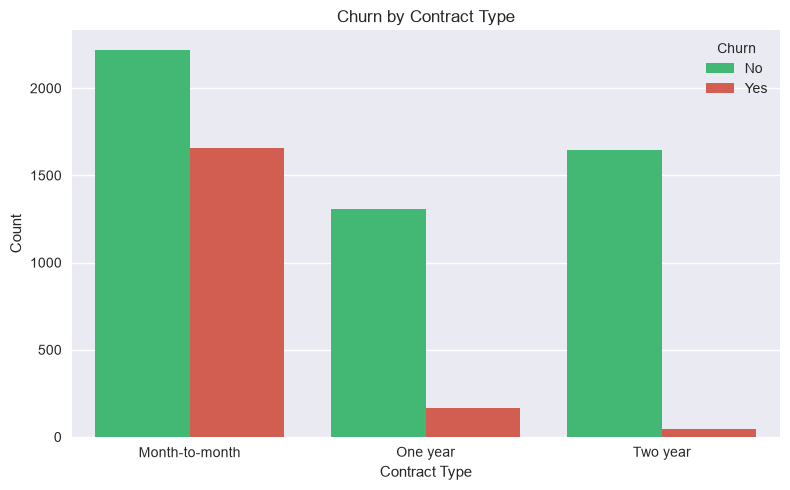

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

# Numbers
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100)

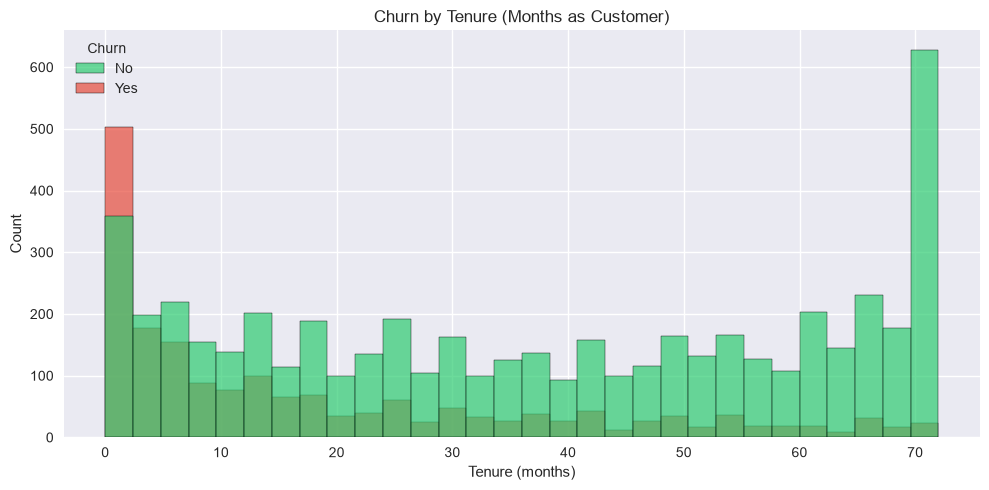

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Churn by Tenure (Months as Customer)')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14676\3619386211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71','#e74c3c'])


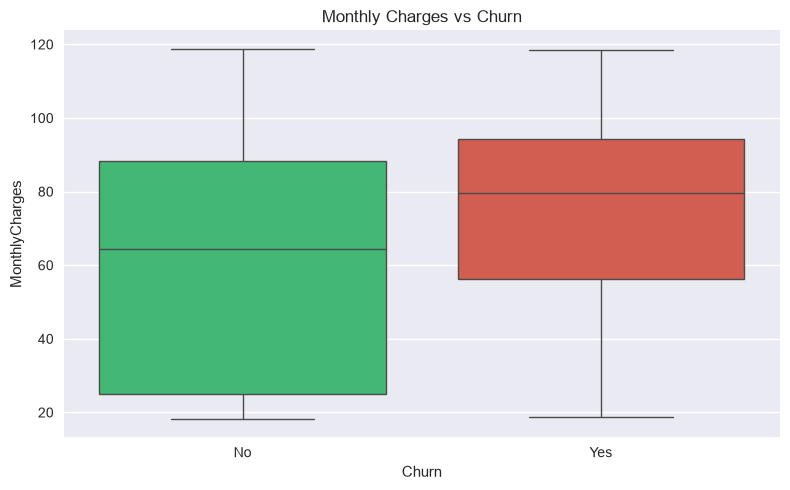

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].mean())

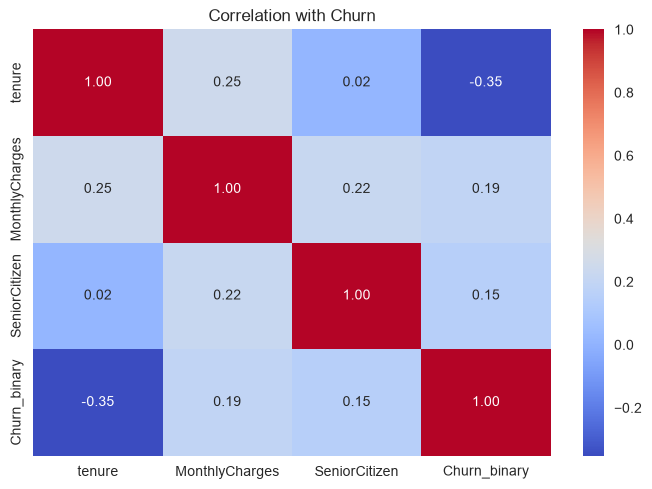

In [9]:
numeric_cols = df[['tenure', 'MonthlyCharges', 'SeniorCitizen']].copy()
numeric_cols['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(7,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with Churn')
plt.tight_layout()
plt.show()

In [10]:
print("=" * 50)
print("EDA SUMMARY — CONSULTING INSIGHTS")
print("=" * 50)
print(f"Total customers: {len(df)}")
print(f"Churn rate: {(df['Churn']=='Yes').mean()*100:.1f}%")
print(f"\n📌 Insight 1: Month-to-month contract customers churn at ~43%")
print(f"📌 Insight 2: Most churn happens in first 12 months of tenure")
print(f"📌 Insight 3: Churned customers pay ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.0f}/mo vs ${df[df['Churn']=='No']['MonthlyCharges'].mean():.0f}/mo retained")
print("\nNext Step → Phase 2: Data Preprocessing")

EDA SUMMARY — CONSULTING INSIGHTS
Total customers: 7043
Churn rate: 26.5%

📌 Insight 1: Month-to-month contract customers churn at ~43%
📌 Insight 2: Most churn happens in first 12 months of tenure
📌 Insight 3: Churned customers pay $74/mo vs $61/mo retained

Next Step → Phase 2: Data Preprocessing
